Dataset Loaded Successfully
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  

Dataset Cleaned Successfully

Feature Engineering Completed

Training Linear Regression Model...

Model Accuracy: 0.06 %

Predicted Temperature After 30 Days:
15.16 °C

Model Saved Successfully


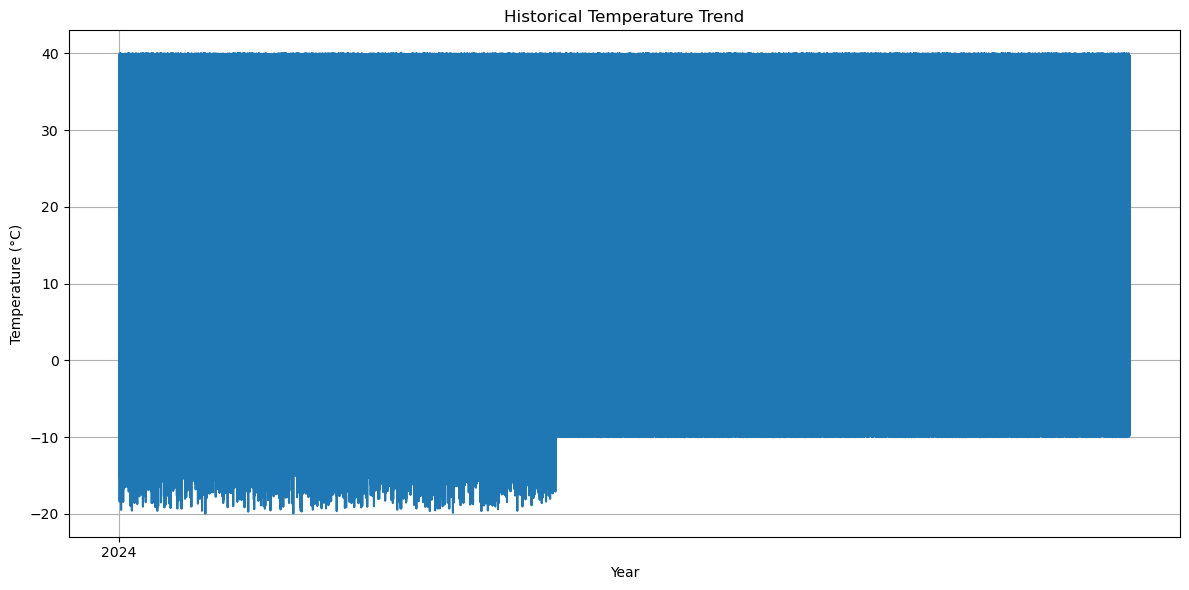

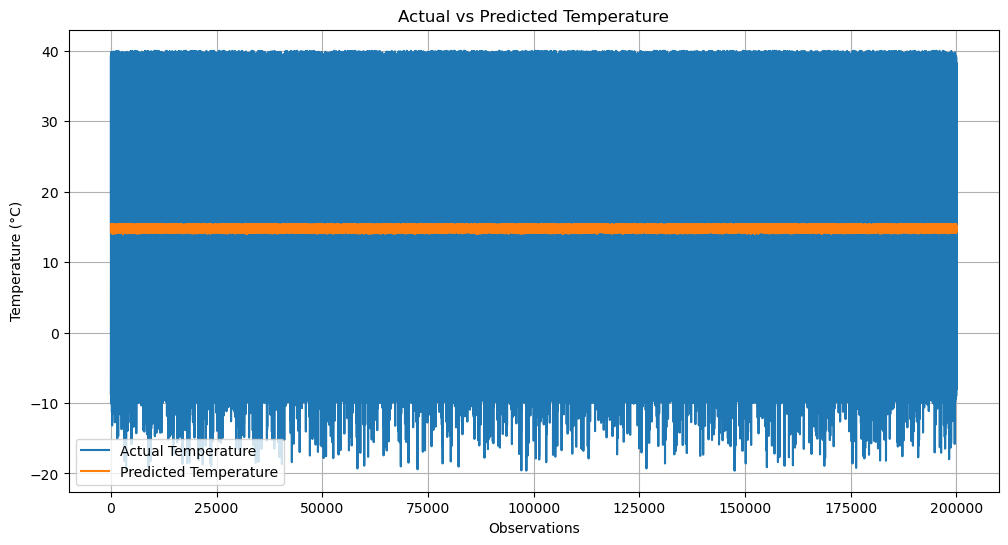


Project Completed Successfully


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# =====================================
# LOAD DATASET
# =====================================

df = pd.read_csv("weather_data.csv")

print("Dataset Loaded Successfully")
print(df.head())

# =====================================
# DATA CLEANING
# =====================================

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Date_Time'] = pd.to_datetime(df['Date_Time'])

df.sort_values('Date_Time', inplace=True)
df.reset_index(drop=True, inplace=True)

print("\nDataset Cleaned Successfully")

# =====================================
# FEATURE ENGINEERING
# =====================================

df['Day_Number'] = np.arange(len(df))

X = df[
    [
        'Day_Number',
        'Humidity_pct',
        'Precipitation_mm',
        'Wind_Speed_kmh'
    ]
]

y = df['Temperature_C']

print("\nFeature Engineering Completed")

# =====================================
# TRAIN TEST SPLIT
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =====================================
# TRAIN MODEL
# =====================================

print("\nTraining Linear Regression Model...")

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = model.score(X_test, y_test)

print("\nModel Accuracy:", round(accuracy * 100, 2), "%")

# =====================================
# FUTURE TEMPERATURE PREDICTION
# =====================================

future_day = len(df) + 30

avg_humidity = df['Humidity_pct'].mean()
avg_precipitation = df['Precipitation_mm'].mean()
avg_wind = df['Wind_Speed_kmh'].mean()

future_input = pd.DataFrame({
    'Day_Number': [future_day],
    'Humidity_pct': [avg_humidity],
    'Precipitation_mm': [avg_precipitation],
    'Wind_Speed_kmh': [avg_wind]
})

future_temp = model.predict(future_input)[0]

print("\nPredicted Temperature After 30 Days:")
print(round(future_temp, 2), "°C")

# =====================================
# SAVE MODEL
# =====================================

with open("weather_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("\nModel Saved Successfully")

# =====================================
# GRAPH 1
# =====================================

plt.figure(figsize=(12,6))

plt.plot(
    df['Date_Time'],
    df['Temperature_C']
)

plt.title("Historical Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.grid(True)
plt.tight_layout()
plt.show()

# =====================================
# GRAPH 2
# =====================================

plot_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})

plot_df.reset_index(drop=True, inplace=True)

plt.figure(figsize=(12,6))

plt.plot(
    plot_df['Actual'],
    label='Actual Temperature'
)

plt.plot(
    plot_df['Predicted'],
    label='Predicted Temperature'
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Observations")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)

plt.show()

print("\nProject Completed Successfully")
